1. Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

ModuleNotFoundError: No module named 'tensorflow'

1. Data Loading and Preprocessing:                                                                                      
• Load the Fashion-MNIST dataset from keras datasets 
• Load the training and test images along with their labels  
• Normalize the pixel values to the range [0, 1] 
• Reshape the images appropriately for input to a CNN (e.g., (28, 28, 1) for grayscale 
images) 
• Provide a few sample images with their corresponding labels. 

In [ ]:
# Load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training Shape: (60000, 28, 28, 1)
Testing Shape: (10000, 28, 28, 1)


Display Sample Images

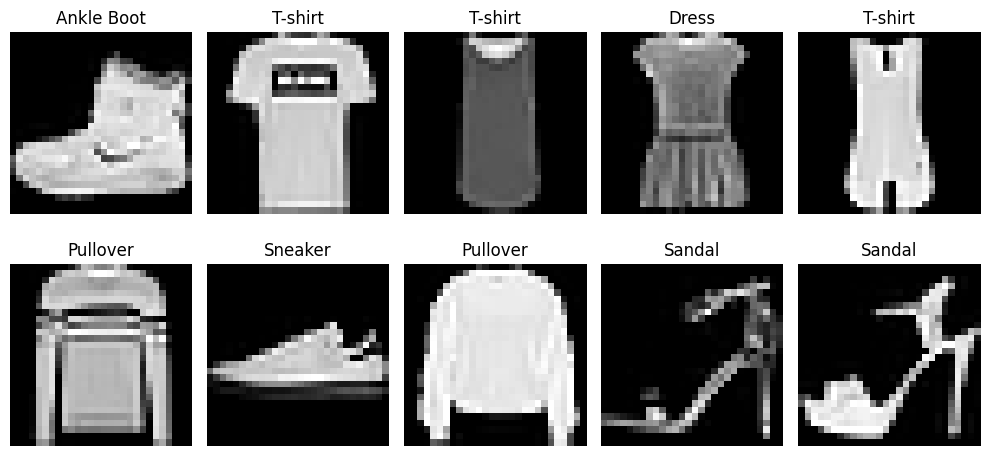

In [ ]:
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress',
               'Coat', 'Sandal', 'Shirt', 'Sneaker',
               'Bag', 'Ankle Boot']

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

2. Design / Build the CNN Model:                                                                                        (Marks 2) 
• Design a multi-layer Convolutional Neural Network using TensorFlow/Keras 
• Include at least: 
o 2 convolutional layers  
o MaxPooling layers  
o Dropout for regularization  
o Flatten layer before the dense layers  
o Dense layers leading to the output layer  
• Compile the model using an appropriate optimizer, loss function, and evaluation metric for 
classification

In [ ]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Dropout(0.25),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

3. Compile and Train your Model:                                                                                        (Marks 2) 
• Train the CNN using the training dataset 
• Use a validation split (e.g., 10–20%) to monitor the model performance during training 
• Train the model for a sufficient number of epochs to achieve stable accuracy 
• Display the training and validation accuracy/loss per epoch  

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

 Train Model

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 62s 81ms/step - accuracy: 0.7670 - loss: 0.6396 - val_accuracy: 0.8558 - val_loss: 0.4026
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 59ms/step - accuracy: 0.8458 - loss: 0.4297 - val_accuracy: 0.8720 - val_loss: 0.3438
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.8641 - loss: 0.3755 - val_accuracy: 0.8817 - val_loss: 0.3112
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 56ms/step - accuracy: 0.8748 - loss: 0.3449 - val_accuracy: 0.8925 - val_loss: 0.2919
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 100s 79ms/step - accuracy: 0.8823 - loss: 0.3225 - val_accuracy: 0.8972 - val_loss: 0.2802
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 71s 65ms/step - accuracy: 0.8896 - loss: 0.3050 - val_accuracy: 0.9003 - val_loss: 0.2666
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.8951 - loss: 0.2865 - val_accuracy: 0.9052 - val_loss: 0.2563
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.8985 - loss: 0.2766 -

4. Model Evaluation:                                                                                                            (Marks 2) 
• Evaluate the trained model on the unseen test dataset 
• Report the test accuracy and loss 
• Generate a confusion matrix and classification report showing performance on different 
fashion categories 

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9057 - loss: 0.2609
Test Loss: 0.26094162464141846
Test Accuracy: 0.9057000279426575


Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


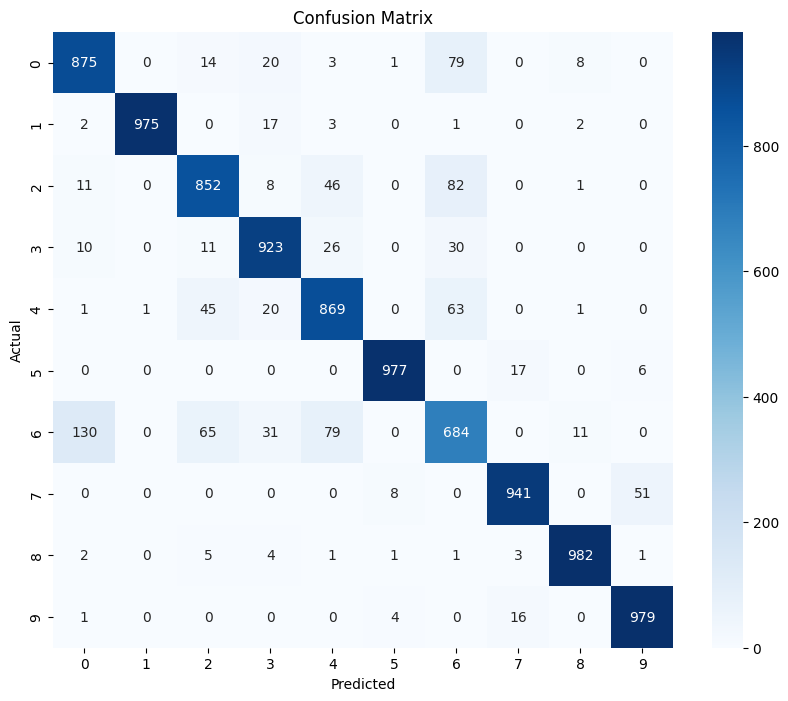

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Classification Report

In [ ]:
print(classification_report(
    y_test,
    y_pred_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

     T-shirt       0.85      0.88      0.86      1000
     Trouser       1.00      0.97      0.99      1000
    Pullover       0.86      0.85      0.86      1000
       Dress       0.90      0.92      0.91      1000
        Coat       0.85      0.87      0.86      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.73      0.68      0.71      1000
     Sneaker       0.96      0.94      0.95      1000
         Bag       0.98      0.98      0.98      1000
  Ankle Boot       0.94      0.98      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



5. Visualization and Analysis of the results:                                                                        (Marks 2) 
• Plot the training loss and accuracy curves across epochs 
• Plot a few test images along with the predicted and true labels
Accuracy Curve

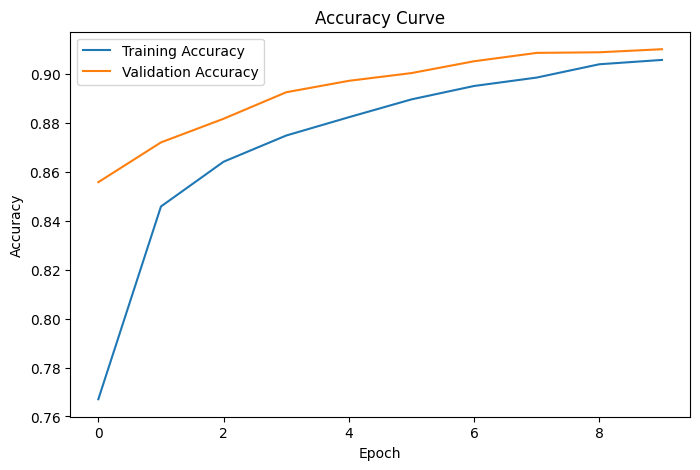

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

 Loss Curve

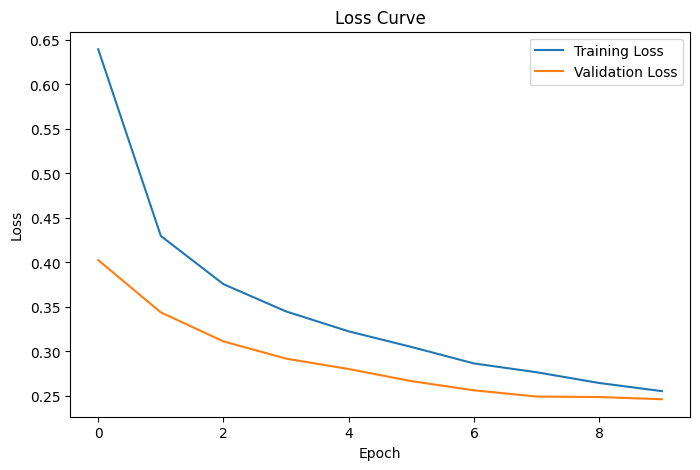

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

 Show Predictions

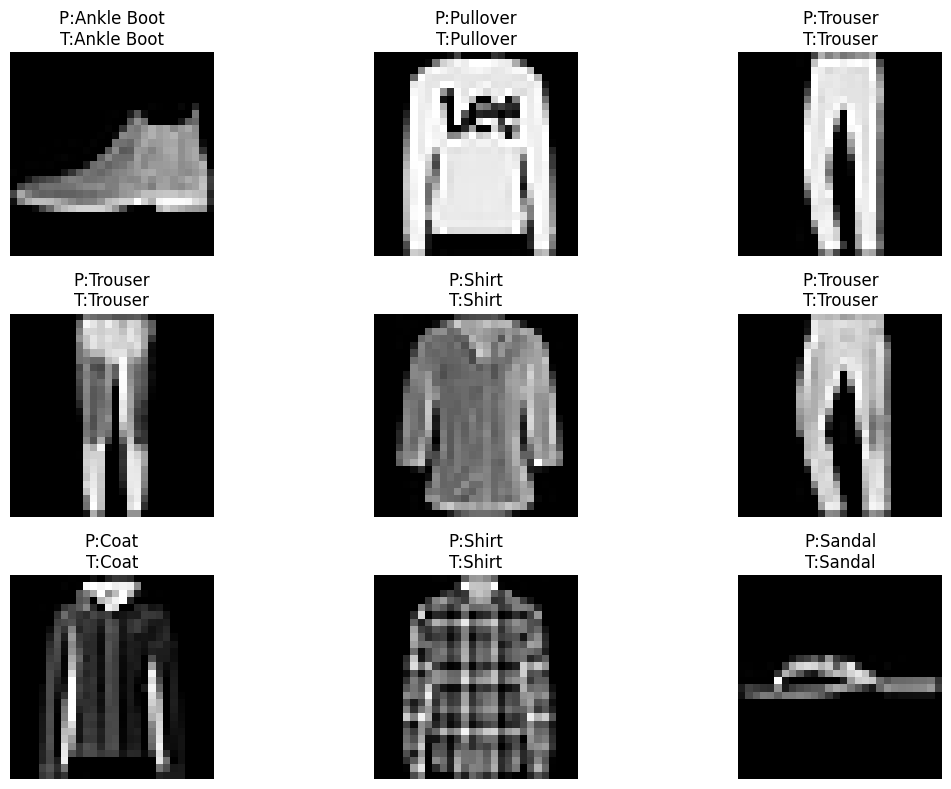

In [ ]:
plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[i].reshape(28,28),
               cmap='gray')

    pred = class_names[y_pred_classes[i]]
    true = class_names[y_test[i]]

    plt.title(f"P:{pred}\nT:{true}")

    plt.axis('off')

plt.tight_layout()
plt.show()